Finding featuers using random forest

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


--- Cross‑validation (Training Set) ---
CV R² scores: [0.86413727 0.92483715 0.94378138 0.92803141 0.96107217]
Mean CV R²: 0.9244

--- Test Set Performance (Strict Feature Set) ---
R²:   0.8722
RMSE: 0.0920
MAE:  0.0666


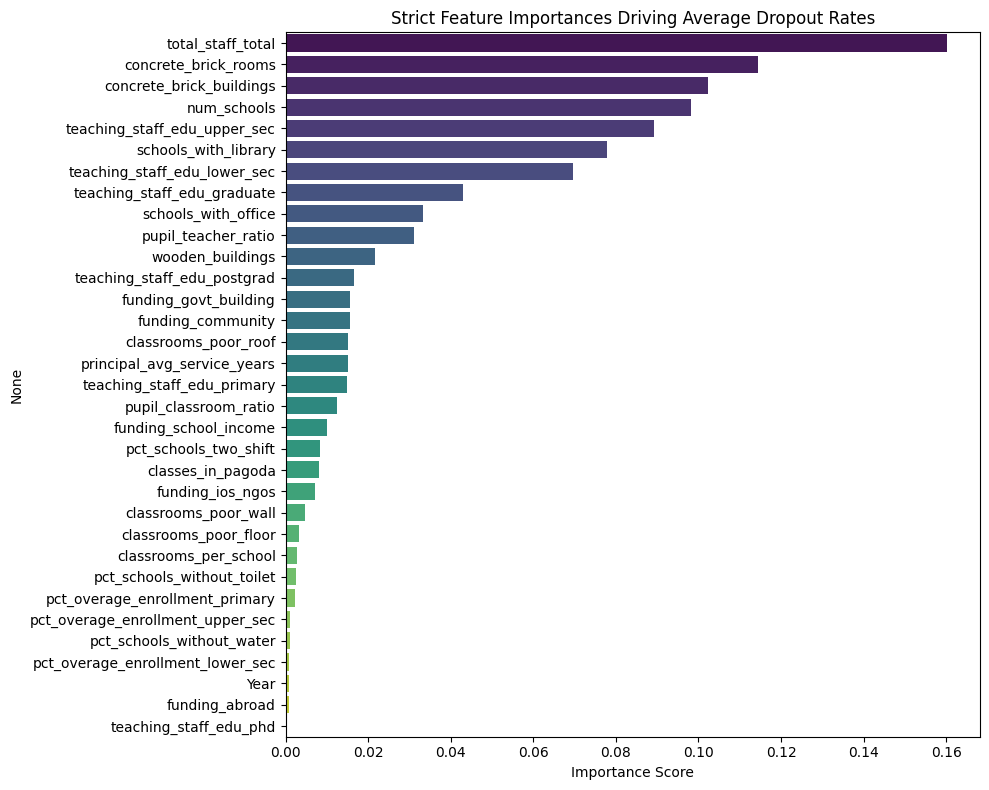


--- Clean Feature Importances ---
total_staff_total                   0.160171
concrete_brick_rooms                0.114446
concrete_brick_buildings            0.102328
num_schools                         0.098190
teaching_staff_edu_upper_sec        0.089118
schools_with_library                0.077932
teaching_staff_edu_lower_sec        0.069658
teaching_staff_edu_graduate         0.043003
schools_with_office                 0.033352
pupil_teacher_ratio                 0.031061
wooden_buildings                    0.021564
teaching_staff_edu_postgrad         0.016585
funding_govt_building               0.015711
funding_community                   0.015556
classrooms_poor_roof                0.015237
principal_avg_service_years         0.015064
teaching_staff_edu_primary          0.014774
pupil_classroom_ratio               0.012512
funding_school_income               0.009984
pct_schools_two_shift               0.008314
classes_in_pagoda                   0.008115
funding_ios_ngos    

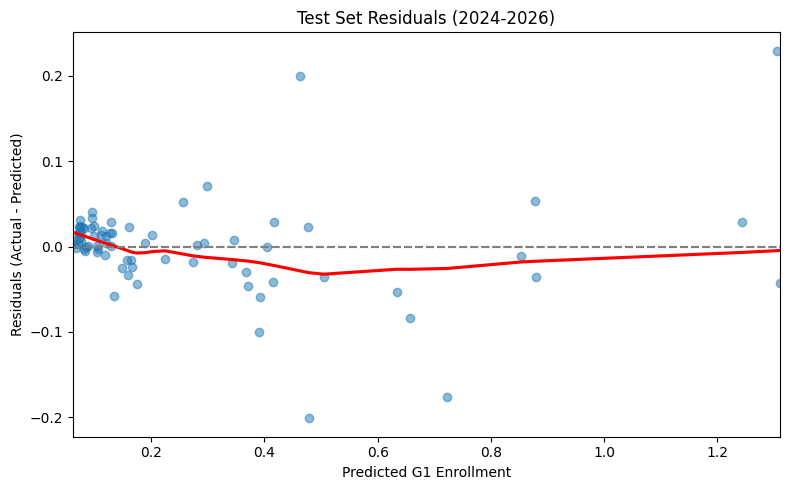

In [12]:
# ------------------------------
# 1. Load Data, Drop 2021 Outliers, & Engineer Target
# ------------------------------
df = pd.read_csv('cleaned_new_data.csv')

# Drop COVID anomaly year
df = df[df['Year'] != 2021].reset_index(drop=True)

# Generate system-wide average dropout target
dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
enrollment_cols = [f'g{i}_enrollment_total' for i in range(1, 13)]

df['total_system_dropouts'] = df[dropout_cols].sum(axis=1)
df['total_system_enrollment'] = df[enrollment_cols].sum(axis=1)
df['avg_system_dropout_rate'] = (df['total_system_dropouts'] / df['total_system_enrollment']) * 100
df['avg_system_dropout_rate'] = df['avg_system_dropout_rate'].fillna(0)

target = 'avg_system_dropout_rate'

# ------------------------------
# 2. DEFINE YOUR EXACT FEATURE WHITELIST
# ------------------------------
# We completely bypass banned_cols and metadata drops. We only select these!
feature_whitelist = [
    # General
    "num_schools", "classes_in_pagoda", "total_staff_total",
    # School condition (Fixed typo quote here)
    "pct_schools_without_toilet", "pct_schools_without_water", "principal_avg_service_years",
    # Over-age enrollment
    "pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec",
    # Teacher quality
    "teaching_staff_edu_primary", "teaching_staff_edu_lower_sec", "teaching_staff_edu_upper_sec",
    "teaching_staff_edu_graduate", "teaching_staff_edu_postgrad", "teaching_staff_edu_phd",
    # Classroom quality
    "concrete_brick_buildings", "concrete_brick_rooms", "wooden_buildings",
    # Infrastructure
    "classrooms_poor_floor", "classrooms_poor_roof", "classrooms_poor_wall", "schools_with_office", "schools_with_library",
    # Funding
    "funding_school_income", "funding_community", "funding_govt_building", "funding_abroad", "funding_ios_ngos",
    # Important ratios
    "pupil_teacher_ratio", "pupil_classroom_ratio", "classrooms_per_school", "pct_schools_two_shift"
]

# Ensure Year is kept alongside the whitelist to anchor time trends natively
X_raw = df[['Year'] + feature_whitelist]
y_raw = df[target]

# ------------------------------
# 3. Time‑Based Train/Test Split
# ------------------------------
train_mask = df['Year'].between(2016, 2023)
test_mask  = df['Year'].between(2024, 2026)

X_train = X_raw[train_mask]
X_test  = X_raw[test_mask]
y_train = y_raw[train_mask]
y_test  = y_raw[test_mask]

# ------------------------------
# 4. Impute Missing Values
# ------------------------------
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

# ------------------------------
# 5. Regularized Random Forest Regressor
# ------------------------------
rf_final = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,              # Prevents memorizing historical quirks
    min_samples_leaf=4,       # Groups rows into reliable patterns
    max_features='sqrt',      # Diversifies splits across your features
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_imputed, y_train)

# 5‑fold CV on training set
cv_scores = cross_val_score(rf_final, X_train_imputed, y_train, cv=5, scoring='r2', n_jobs=-1)
print("\n--- Cross‑validation (Training Set) ---")
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

# ------------------------------
# 6. Evaluate on Test Set (2024‑2026)
# ------------------------------
y_pred = rf_final.predict(X_test_imputed)

test_r2   = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)

print("\n--- Test Set Performance (Strict Feature Set) ---")
print(f"R²:   {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

# ------------------------------
# 7. Feature Importance Plot
# ------------------------------
importances = pd.Series(rf_final.feature_importances_, index=X_train_imputed.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Strict Feature Importances Driving Average Dropout Rates')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n--- Clean Feature Importances ---")
print(importances)
# ------------------------------
# 8. Residual plot
# ------------------------------
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('Predicted G1 Enrollment')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Test Set Residuals (2024‑2026)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

Selected features via RFE: ['num_schools', 'num_classes', 'num_schools_primary', 'num_schools_college', 'two_shift_schools_lycee', 'floating_schools_lycee', 'principal_female', 'num_primary_schools', 'satellite_classes', 'pagoda_primary_classes', 'pagoda_senior_high_classes', 'num_rooms_total', 'num_classrooms', 'sport_volleyball', 'sport_football', 'sport_climbing_ropes', 'parent_assoc_exists', 'gross_admission_rate_total', 'total_system_enrollment', 'avg_system_dropout_rate']

--- Cross‑validation (Training Set) ---
CV R² scores: [0.96505107 0.99610106 0.9957363  0.98681284 0.98523843]
Mean CV R²: 0.9858 (+/- 0.0226)

--- Test Set Performance (2024 Suspected Split) ---
R²:   0.9590
RMSE: 1823.1964
MAE:  1283.6153


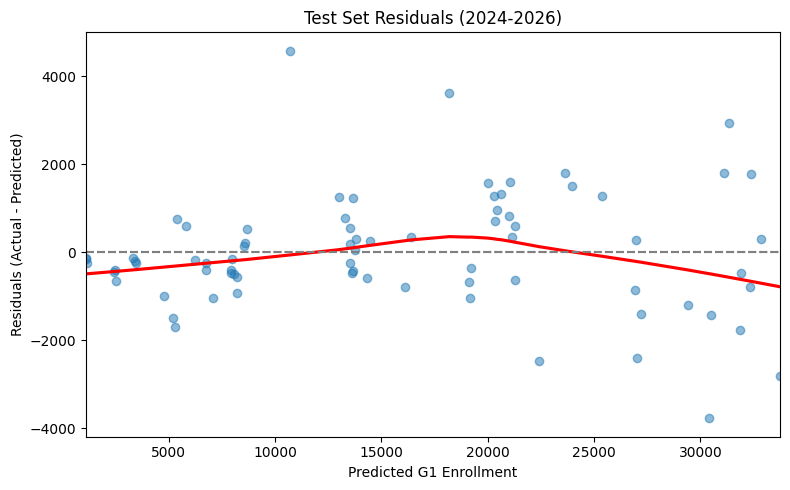

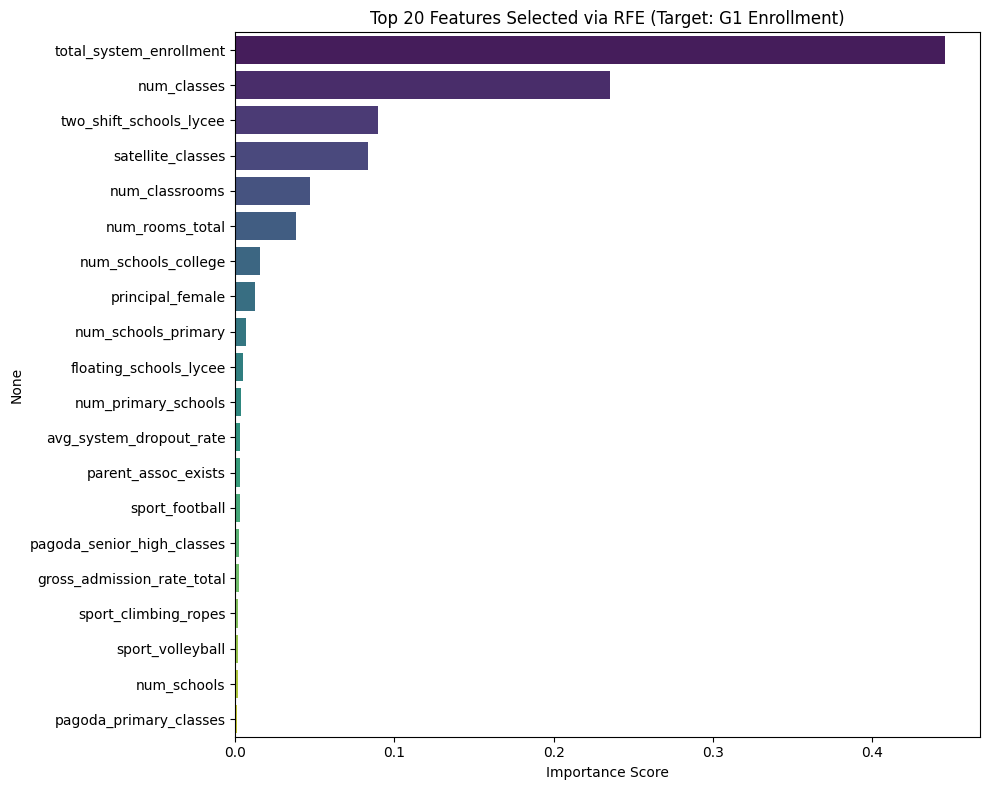


--- Feature Importances (Top 20) ---
total_system_enrollment       0.445761
num_classes                   0.235682
two_shift_schools_lycee       0.089668
satellite_classes             0.083041
num_classrooms                0.046777
num_rooms_total               0.037892
num_schools_college           0.015515
principal_female              0.012329
num_schools_primary           0.006768
floating_schools_lycee        0.004777
num_primary_schools           0.003385
avg_system_dropout_rate       0.002875
parent_assoc_exists           0.002719
sport_football                0.002629
pagoda_senior_high_classes    0.002302
gross_admission_rate_total    0.002162
sport_climbing_ropes          0.001659
sport_volleyball              0.001582
num_schools                   0.001514
pagoda_primary_classes        0.000962
dtype: float64


In [13]:
target = 'g1_enrollment_total'

# Features that contain direct answers or strong scale shortcuts for G1 enrollment
banned_cols = [
    # General totals that create absolute scale leakage
    "enrollment_total", "enrollment_girl", "repeaters_total", "repeaters_girl",
    "teaching_staff_total", "teaching_staff_female", "non_teaching_staff_total", 
    "non_teaching_staff_female", "total_staff_total", "total_staff_female",
    
    # Grade 1-12 raw metrics (Except the target itself, which we handle separately)
    "g1_enrollment_girl", "g1_repeaters_total", "g1_repeaters_girl",
    "g2_enrollment_total", "g2_enrollment_girl", "g2_repeaters_total", "g2_repeaters_girl",
    "g3_enrollment_total", "g3_enrollment_girl", "g3_repeaters_total", "g3_repeaters_girl",
    "g4_enrollment_total", "g4_enrollment_girl", "g4_repeaters_total", "g4_repeaters_girl",
    "g5_enrollment_total", "g5_enrollment_girl", "g5_repeaters_total", "g5_repeaters_girl",
    "g6_enrollment_total", "g6_enrollment_girl", "g6_repeaters_total", "g6_repeaters_girl",
    "g7_enrollment_total", "g7_enrollment_girl", "g7_repeaters_total", "g7_repeaters_girl",
    "g8_enrollment_total", "g8_enrollment_girl", "g8_repeaters_total", "g8_repeaters_girl",
    "g9_enrollment_total", "g9_enrollment_girl", "g9_repeaters_total", "g9_repeaters_girl",
    "g10_enrollment_total", "g10_enrollment_girl", "g10_repeaters_total", "g10_repeaters_girl",
    "g11_enrollment_total", "g11_enrollment_girl", "g11_repeaters_total", "g11_repeaters_girl",
    "g12_enrollment_total", "g12_enrollment_girl", "g12_repeaters_total", "g12_repeaters_girl",
    
    # Student progression/flow metrics
    "g1_promotion", "g1_repetition", "g1_dropout",
    "g2_promotion", "g2_repetition", "g2_dropout",
    "g3_promotion", "g3_repetition", "g3_dropout",
    "g4_promotion", "g4_repetition", "g4_dropout",
    "g5_promotion", "g5_repetition", "g5_dropout",
    "g6_promotion", "g6_repetition", "g6_dropout",
    "g7_promotion", "g7_repetition", "g7_dropout",
    "g8_promotion", "g8_repetition", "g8_dropout",
    "g9_promotion", "g9_repetition", "g9_dropout",
    "g10_promotion", "g10_repetition", "g10_dropout",
    "g11_promotion", "g11_repetition", "g11_dropout",
    "g12_promotion", "g12_repetition", "g12_dropout",
    
    # Raw demographic counts that give away the absolute population scale
    "pop_aged6_total", "pop_aged6_girl",
    "pop_aged6_11_total", "pop_aged6_11_girl",
    "pop_aged12_14_total", "pop_aged12_14_girl",
    "pop_aged15_17_total", "pop_aged15_17_girl",
    
    # Intake totals that share massive correlation with Grade 1 enrollment
    "g1_intake_total", "g1_intake_aged6",
    "primary_enrollment_total", "primary_enrollment_aged11plus",
    "g7_intake_total", "g7_intake_aged12",
    "lower_sec_enrollment_total", "lower_sec_enrollment_aged14plus",
    "g10_intake_total", "g10_intake_aged15",
    "upper_sec_enrollment_total", "upper_sec_enrollment_aged17plus",
    
    # Efficiency overview rates
    "pct_repeaters_total_primary", "pct_repeaters_total_lower_sec", "pct_repeaters_total_upper_sec",
    "pct_overage_total_primary", "pct_overage_total_lower_sec", "pct_overage_total_upper_sec",
    "pct_repeaters_girl_primary", "pct_repeaters_girl_lower_sec", "pct_repeaters_girl_upper_sec",
    "pct_overage_girl_primary", "pct_overage_girl_lower_sec", "pct_overage_girl_upper_sec",
    "pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec"
]

metadata_cols = ['row_id', 'Year', 'Province']

# ------------------------------
# 3. Time‑based train/test split
# ------------------------------
train_mask = df['Year'].between(2016, 2023)
test_mask  = df['Year'].between(2024, 2026)

numeric_df = df.select_dtypes(include=['number'])

# Clean feature extraction (Explicitly drop target here to avoid removing it too early above)
X_raw = numeric_df.drop(columns=banned_cols + metadata_cols + [target], errors='ignore')
y_raw = numeric_df[target]

# Apply masks
X_train = X_raw[train_mask]
X_test  = X_raw[test_mask]
y_train = y_raw[train_mask]
y_test  = y_raw[test_mask]

# ------------------------------
# 4. Impute missing values (fit on train only)
# ------------------------------
imputer = SimpleImputer(strategy='median')
# Rebuilding pandas DataFrames preserves column alignment
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

# ------------------------------
# 5. RFE with Random Forest (train only)
# ------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Step=2 performs cleaner feature elimination without breaking dynamic correlations
selector = RFE(rf, n_features_to_select=20, step=2)
selector.fit(X_train_imputed, y_train)

selected_features = X_train_imputed.columns[selector.support_].tolist()
print(f"Selected features via RFE: {selected_features}")

# Build final datasets using selected columns
X_train_selected = X_train_imputed[selected_features]
X_test_selected  = X_test_imputed[selected_features]

# ------------------------------
# 6. Train final model & cross‑validate
# ------------------------------
rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_selected, y_train)

cv_scores = cross_val_score(rf_final, X_train_selected, y_train, cv=5, scoring='r2', n_jobs=-1)
print("\n--- Cross‑validation (Training Set) ---")
print(f"CV R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ------------------------------
# 7. Evaluate on the test set (2024‑2026)
# ------------------------------
y_pred = rf_final.predict(X_test_selected)

test_r2   = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae  = mean_absolute_error(y_test, y_pred)

print("\n--- Test Set Performance (2024 Suspected Split) ---")
print(f"R²:   {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")

# ------------------------------
# 8. Residual plot
# ------------------------------
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True,
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.xlabel('Predicted G1 Enrollment')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Test Set Residuals (2024‑2026)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

# ------------------------------
# 9. Feature importance plot
# ------------------------------
importances = pd.Series(rf_final.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 20 Features Selected via RFE (Target: G1 Enrollment)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('top_20_features_rfe.png')
plt.show()

print("\n--- Feature Importances (Top 20) ---")
print(importances)